In [5]:
import glob, os
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from ipywidgets import interact, FloatSlider

# ── EDIT THESE ────────────────────────────────────────
INPUT_DIR  = '../data/images/D21'
OUTPUT_DIR = '../data/masks/D21'
# ──────────────────────────────────────────────────────

def load_by_id(folder):
    files = glob.glob(os.path.join(folder, '*.tif'))
    return {int(os.path.basename(f).split('_')[0]): f for f in files}

inputs  = load_by_id(INPUT_DIR)
outputs = load_by_id(OUTPUT_DIR)
matched = sorted(set(inputs) & set(outputs))
print(f'Matched IDs: {matched}')

Matched IDs: [31, 32, 33, 34, 35, 36, 37, 41, 42, 43, 44, 45, 76, 77, 81, 82, 86, 87, 121, 122, 126, 127, 131]


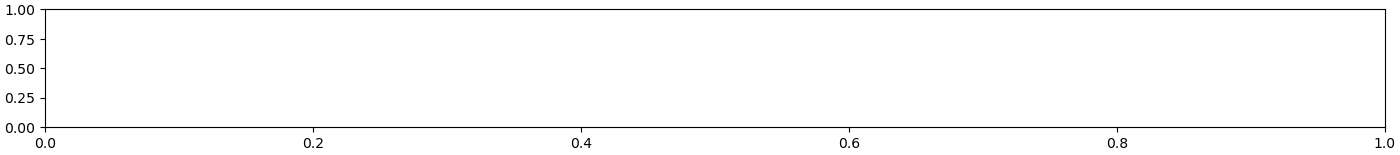

interactive(children=(Dropdown(description='image_id', options=(31, 32, 33, 34, 35, 36, 37, 41, 42, 43, 44, 45…

In [19]:
%matplotlib widget

def normalize(img):
    img = img.astype(float)
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

_sample = imread(inputs[matched[0]])
_sh, _sw = _sample.shape[:2]
_fw = 14
_fh = _fw * _sh / _sw + 0.4   # image height + title lines

fig2, ax2 = plt.subplots(figsize=(_fw, _fh), constrained_layout=True)
plt.show()

def show(image_id, alpha):
    img  = imread(inputs[image_id])
    mask = imread(outputs[image_id]) > 0

    h, w       = img.shape[:2]
    dtype      = img.dtype
    vmin, vmax = img.min(), img.max()
    n_vessel   = mask.sum()
    pct_vessel = 100 * n_vessel / mask.size
    fname_in   = os.path.basename(inputs[image_id])
    fname_out  = os.path.basename(outputs[image_id])

    ax2.cla()
    ax2.imshow(normalize(img), cmap='gray')

    mask_rgba       = np.zeros((*mask.shape, 4))
    mask_rgba[mask] = [1, 0, 0, alpha]
    ax2.imshow(mask_rgba)

    ax2.set_title(
        f'Input: {fname_in}  |  Output: {fname_out}\n'
        f'red = vessel lumen  |  {w}x{h} px  |  {dtype}  |  '
        f'range [{vmin}, {vmax}]  |  vessel {n_vessel:,} px ({pct_vessel:.1f}%)',
        fontsize=9, loc='left', pad=2
    )
    ax2.axis('off')
    fig2.canvas.draw_idle()

interact(
    show,
    image_id = matched,
    alpha    = FloatSlider(value=0.4, min=0.0, max=1.0, step=0.05,
                           description='Mask alpha', continuous_update=False)
);

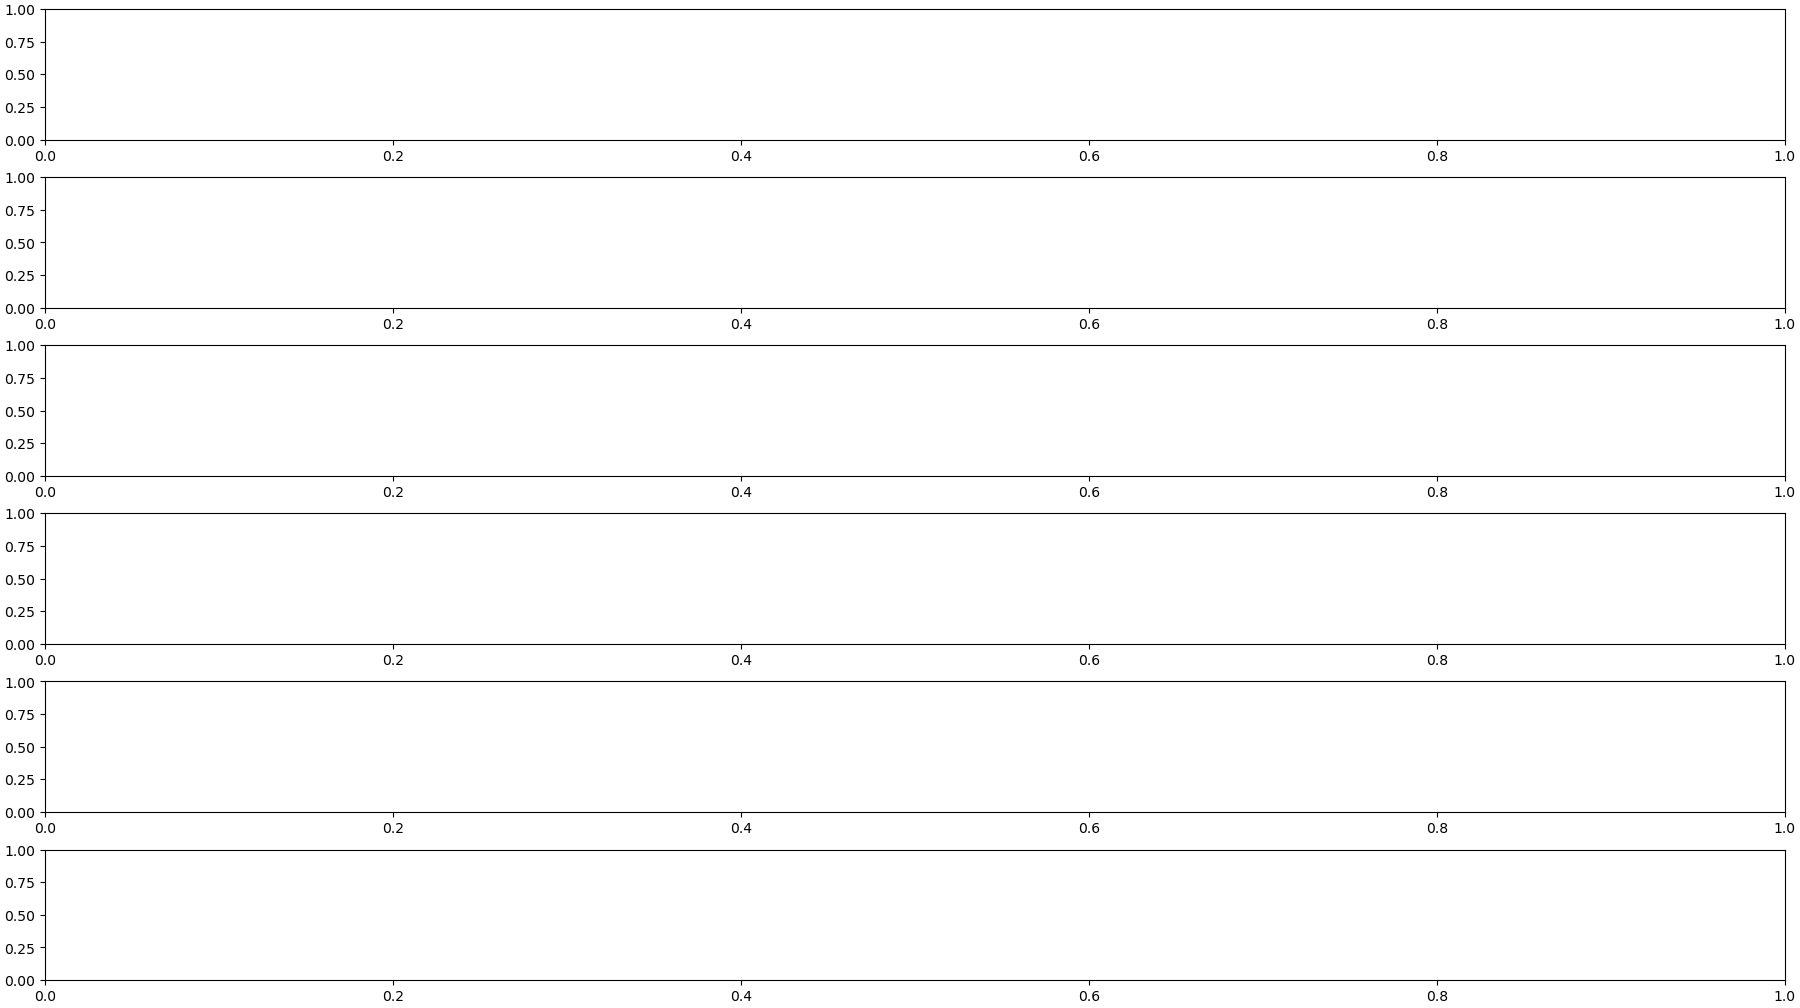

interactive(children=(FloatSlider(value=0.6, continuous_update=False, description='Overlay alpha', max=1.0, st…

In [22]:
%matplotlib widget
import ipywidgets as widgets

# ── EDIT THESE ────────────────────────────────────────
# ----- 117 ----- 
IMAGE_PATH = '../inference_data/91-135/117_EC_D14_P1_C1_MAX_Crop.tif'
GT_PATH    = '../inference_data/Ground_Truth_117_132/117_EC_D14_P1_C1_MAX_Crop_mask_cleaned_erase.tif'
PRED_PATH  = '../predictions/91-135/117_EC_D14_P1_C1_MAX_Crop_mask.tif'

# ----- 132 ----- 
# IMAGE_PATH = '../inference_data/91-135/132_EC_D21_P1_C1_MAX_Crop.tif'
# GT_PATH    = '../inference_data/Ground_Truth_117_132/132_EC_D21_P1_C1_MAX_Crop_mask_cleaned_erase.tif'
# PRED_PATH  = '../predictions/91-135/132_EC_D21_P1_C1_MAX_Crop_mask.tif'
# ──────────────────────────────────────────────────────

RED, GREEN, YELLOW = (
    np.array([255,   0,   0]),
    np.array([  0, 220,   0]),
    np.array([255, 220,   0]),
)

_img   = imread(IMAGE_PATH)
_h, _w = _img.shape[:2]
_fw    = 18
_fh    = (_fw * _h / _w + 0.2) * 6   # 6 panels

fig, axes = plt.subplots(6, 1, figsize=(_fw, _fh), constrained_layout=True)
plt.show()

def show_comparison(alpha):
    gt   = imread(GT_PATH)   > 0
    pred = imread(PRED_PATH) > 0

    tp = pred &  gt
    fp = pred & ~gt
    fn = ~pred &  gt
    dice = (2.0 * tp.sum()) / (pred.sum() + gt.sum() + 1e-8)

    img_u8  = (normalize(_img) * 255).astype(np.uint8)
    img_rgb = np.stack([img_u8] * 3, axis=-1)

    def blend(mask, color):
        out = img_rgb.copy()
        out[mask] = (alpha * color + (1 - alpha) * out[mask]).astype(np.uint8)
        return out

    combined = img_rgb.copy()
    combined[tp] = (alpha * GREEN  + (1 - alpha) * combined[tp]).astype(np.uint8)
    combined[fp] = (alpha * RED    + (1 - alpha) * combined[fp]).astype(np.uint8)
    combined[fn] = (alpha * YELLOW + (1 - alpha) * combined[fn]).astype(np.uint8)

    panels = [
        (combined,            f'Combined — green=TP  red=FP  yellow=FN  |  Dice: {dice:.4f}'),
        (blend(gt,   GREEN),  f'Ground Truth — green = vessel'),
        (blend(pred, RED),    f'Prediction — red = predicted vessel'),
        (blend(tp,   GREEN),  f'TP (True Positive): {tp.sum():,} px — predicted vessel, confirmed vessel by GT'),
        (blend(fp,   RED),    f'FP (False Positive): {fp.sum():,} px — predicted vessel, actually background'),
        (blend(fn,   YELLOW), f'FN (False Negative): {fn.sum():,} px — predicted background, actually vessel (missed)'),
    ]

    fig.suptitle(os.path.basename(IMAGE_PATH), fontsize=11, fontweight='bold')
    for ax, (panel, label) in zip(axes, panels):
        ax.cla()
        ax.imshow(panel)
        ax.set_title(label, fontsize=9, loc='left', pad=2)
        ax.axis('off')
    fig.canvas.draw_idle()

interact(
    show_comparison,
    alpha = FloatSlider(value=0.6, min=0.0, max=1.0, step=0.05,
                        description='Overlay alpha', continuous_update=False)
);